##

##

In [55]:
# loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import shap

In [56]:
# machine learning regression
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans

from xgboost import XGBRegressor , XGBClassifier
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

In [57]:
# Machine Leraning Classify
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

In [58]:
#=========================================================
#  Load dataset and checking nan
#=========================================================

df_original = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
print(f"total number of rows and columns in the dataset: {len(df_original.columns) + 1} columns, {len(df_original) + 1} rows")


# Grouping years into decodes
def Grouping_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    print(year_counts)
    

    return df

df_Grouping_year = Grouping_date_to_year(df_original)

# Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

Missing  = nan_check(df_Grouping_year)
Missing

total number of rows and columns in the dataset: 49 columns, 9666 rows
Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


,Total,%
City_Town_3,8728,90.3
City_Town_2,4943,51.1
City_Town,437,4.5
State_Island_Province,36,0.4
SSTA_Minimum,12,0.1
SSTA_FrequencyMax,5,0.1
SSTA_Standard_Deviation,5,0.1
TSA_Maximum,5,0.1
SSTA_Maximum,5,0.1
SSTA_Frequency,5,0.1


In [59]:
#=================================================
# Function analysis variable for Cleaning data
#=================================================
def Columns_percent_missing(df,df_dtype, col):
    
    count_less = 0
    count_more = 0
    Index_more = []
    Index_less = []
    for_drop = []
    type_object = []
    type_number = []
    for idx, value in df[col].items():
        if value >= 0.4:
            count_more += 1
            Index_more.append(idx)
            for_drop.append(idx)
        elif value < 0.4:
            count_less += 1
            Index_less.append(idx)
            
    for i in df_dtype.columns:
        if df_dtype[i].dtype == 'object':
            type_object.append(i)
        else:
            type_number.append(i)

    print("\n")
    print(f"more than 0.4% : {count_more}")
    print(f"less than 0.4% : {count_less}")
    print(f"Name_of_moreNAN : {len(Index_more)} attribuue : {Index_more}")
    print(f"Name_of_lessNAN : {len(Index_less)} attribuue : {Index_less}")
    print(f"for_drop : {len(for_drop)} attribuue : {for_drop}")
    print(f"object type : {len(type_object)} attribue : {type_object}")
    print(f"number type : {len(type_number)} attribue : {type_number}")

    return for_drop , type_object
    
columns_drop, col_object = Columns_percent_missing(Missing, df_original, '%')
print("="*80)
print(">>>>>>>  Missing values more than 0.4% : Delete <<<<<<<<")
print("="*80)



more than 0.4% : 4
less than 0.4% : 45
Name_of_moreNAN : 4 attribuue : ['City_Town_3', 'City_Town_2', 'City_Town', 'State_Island_Province']
Name_of_lessNAN : 45 attribuue : ['SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_Standard_Deviation', 'TSA_Maximum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_Mean', 'SSTA_FrequencyMean', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'SSTA', 'Temperature_Minimum', 'Temperature_Maximum', 'TSA_Minimum', 'Temperature_Mean', 'Temperature_Kelvin', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'TSA_Standard_Deviation', 'Windspeed', 'ClimSST', 'ID', 'Latitude_Degrees', 'Average_Bleaching', 'Depth', 'Date2', 'Date', 'Country_Name', 'Ecoregion', 'Realm', 'Ocean', 'Longitude_Degrees', 'Year']
for_drop : 4 attribuue : ['City

In [60]:
#=========================================
# Cleaning data
#=========================================
def Clean_data_paper(df, col_object, col_dont_need):
    
    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
    df = df[df['SSTA'] > 0] # เลือกเฉพาะคที่มีค่า SSTA มากกว่า 0 เเละ NaN จะถูกละทิ้งไปโดยอัตโนมัติ
    
    df_object = df.drop(columns=col_object) # ลบคอลัมน์ที่เป็น Object ออกเเละค่าที่ไม่จำเป็นออกไป
    df_dont_need = df_object.drop(columns=col_dont_need) # ลบคอลัมน์ที่ไม่จำเป็นออกไป

    df = df_dont_need.rename(columns={"Depth": "Depth_m", "Average_Bleaching": "Percent_Bleaching"}) # เปลี่ยนชื่อคอลัมน์ให้สั้นลง เเละเจข้าใจง่ายขึ้น

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'],errors='coerce')
    
    return df

col_dont_need = ['ID', 'Date', 'Date2', 'SSTA_Mean']
df_Clean_already = Clean_data_paper(df_Grouping_year, col_object, col_dont_need)
df_Clean_already = df_Clean_already.fillna(method='ffill')
print("="*200)
print(f"{col_object} >>>>> {col_dont_need} : {len(col_object) + len(col_dont_need)} >>>>>>>> {len(df_original.columns) - len(col_object) - len(col_dont_need)}")
print(f"total number of rows and columns in the dataset: {len(df_Clean_already.columns)} columns, {len(df_Clean_already)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")
print("="*200)

['Ocean', 'Realm', 'Ecoregion', 'Country_Name', 'State_Island_Province', 'City_Town', 'City_Town_2', 'City_Town_3'] >>>>> ['ID', 'Date', 'Date2', 'SSTA_Mean'] : 12 >>>>>>>> 37
total number of rows and columns in the dataset: 37 columns, 6112 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


C:\Users\superuser\AppData\Local\Temp\ipykernel_8088\4233094419.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
C:\Users\superuser\AppData\Local\Temp\ipykernel_8088\4233094419.py:26: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_Clean_already = df_Clean_already.fillna(method='ffill')


## ***ตัวแปรที่เก็บ data เเละพร้อมใช้งานสำหรับการนำไปวิเคราะห์ df_Clean_already***

##

##

### - **Exploratory Data Analysis**

In [61]:
#===============================================
# Total Function 
#===============================================

def Plotting_feature_target(df,col_feature, col_target='Percent_Bleaching'):
    
    X = df[col_feature]
    y = df[col_target]
    
    plt.figure(figsize=(6,4))
    plt.scatter(X, y, color='white', edgecolor='black', alpha=0.7)
    plt.xlabel(col_feature)
    plt.ylabel(col_target)
    plt.title(f'{col_feature} vs {col_target}')
    plt.show()
    
    
def Create_Feature_from_equetion(df, O1, O2,f):
    
    from scipy.stats import pearsonr, spearmanr

    transforms = {
        'feature_En is '+ f: df[f],
        'original1 is ' + O1: df[O1],
        'original2 is ' + O2: df[O2]
        
    }

    for name, col in transforms.items():
        r, _ = spearmanr(col, df['Percent_Bleaching'])
        print(f"{name}: Spearman r = {r:.4f}")
        
    print("="*50)
    
    for name, col in transforms.items():
        r, _ = pearsonr(col, df['Percent_Bleaching'])
        print(f"{name}: Pearsonr r = {r:.4f}")

In [62]:
df_exploratory = df_Clean_already.copy()

In [63]:
# 1. สร้างคอลัมน์ 'Bin' เพื่อช่วยในการแบ่ง (Stratification)
# แบ่งเป็น 0 (ไม่ฟอก) กับ 1 (ฟอกขาว)
df_exploratory['Classify'] = (df_exploratory['Percent_Bleaching'] >= 1).astype(int)
print(df_exploratory[['Classify']].value_counts())
print('='*40)
print(f"Original feature : {len(df_Clean_already.columns)} ---> become {len(df_exploratory.columns)}")

Classify
0           4513
1           1599
Name: count, dtype: int64
Original feature : 37 ---> become 38


In [64]:
#===============================
# >= 1 is Bleaching
#===============================
Bleaching = df_exploratory[df_exploratory['Classify'] == 1]

In [65]:
# ตรวจก่อนว่ามี Depth_m = 0 ไหม
print(Bleaching['Depth_m'].describe())
print(f"Depth_m = 0: {(Bleaching['Depth_m'] == 0).sum()} rows")
print(f"Depth_m < 0: {(Bleaching['Depth_m'] < 0).sum()} rows")

# สร้าง feature พร้อม guard
epsilon = 1e-9  # ป้องกัน division by zero

Bleaching['SSTA_DHW_TSA_DHW']  = (
    Bleaching['SSTA_DHW'] / np.sqrt(Bleaching['Depth_m'])
)

# ตรวจ NaN / inf หลังสร้าง
print(Bleaching[['SSTA_DHW_TSA_DHW']].isin([np.inf, -np.inf]).sum())
print(Bleaching[['SSTA_DHW_TSA_DHW']].isna().sum())

count    1599.000000
mean        6.737336
std         3.630022
min         0.100000
25%         4.000000
50%         6.000000
75%        10.000000
max        21.700000
Name: Depth_m, dtype: float64
Depth_m = 0: 0 rows
Depth_m < 0: 0 rows
SSTA_DHW_TSA_DHW    0
dtype: int64
SSTA_DHW_TSA_DHW    0
dtype: int64


C:\Users\superuser\AppData\Local\Temp\ipykernel_8088\1023250813.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bleaching['SSTA_DHW_TSA_DHW']  = (


In [66]:
Create_Feature_from_equetion(Bleaching, 'SSTA_DHW','Depth_m', 'SSTA_DHW_TSA_DHW')

feature_En is SSTA_DHW_TSA_DHW: Spearman r = 0.1665
original1 is SSTA_DHW: Spearman r = 0.1744
original2 is Depth_m: Spearman r = -0.0193
feature_En is SSTA_DHW_TSA_DHW: Pearsonr r = 0.1933
original1 is SSTA_DHW: Pearsonr r = 0.2526
original2 is Depth_m: Pearsonr r = 0.0092


In [67]:
Bleaching[['Windspeed']].describe()

,Windspeed
count,1599.000000
mean,4.886804
std,2.023101
min,0.000000
25%,3.000000
50%,5.000000
75%,6.000000
max,14.000000


##

##

### **Principle component Analysis (PCA)**
- feature follow paper : ClimSST , Depth_m , Latitude , Longitude , SSTA
- feature Additive : SSTA_DHW , Temperature_Kelvin

In [68]:
df_principal = df_Clean_already.copy()

In [69]:
def Grouping_data(df, col_groupby, name_new_col, cols_keep=None):
    df_new = df.copy()
    df_new = df_new[col_groupby]
    print(f"Groupby name is : {name_new_col}")
    
    return df_new

In [70]:
col_paper = [
                'Latitude_Degrees',
                'Longitude_Degrees',
                'ClimSST',
                'Depth_m',
                'SSTA'
            ]
df_paper_groupby = Grouping_data(df_principal, col_paper, 'paper_groupby')
#-----------------------------------------------------------------------------------------------------
col_Additive = [
                    'SSTA_DHW',
                    'Temperature_Kelvin'
               ]
df_Additive_groupby = Grouping_data(df_Clean_already, col_Additive, 'Additive_groupby')

#-----------------------------------------------------------------------------------------------------
col_Other = df_Clean_already.drop(columns=col_paper + col_Additive + ['Percent_Bleaching']).columns.tolist()
df_Other_groupby = Grouping_data(df_principal, col_Other, 'Other_groupby')

Groupby name is : paper_groupby
Groupby name is : Additive_groupby
Groupby name is : Other_groupby


In [71]:
print("-"*50)
print(df_paper_groupby.isnull().sum())
print("-" * 50)
print(df_Additive_groupby.isnull().sum())
print("-" * 50)
print(df_Other_groupby.isnull().sum())


--------------------------------------------------
Latitude_Degrees     0
Longitude_Degrees    0
ClimSST              0
Depth_m              0
SSTA                 0
dtype: int64
--------------------------------------------------
SSTA_DHW              0
Temperature_Kelvin    0
dtype: int64
--------------------------------------------------
Temperature_Mean                         0
Temperature_Minimum                      0
Temperature_Maximum                      0
Temperature_Kelvin_Standard_Deviation    0
Windspeed                                0
SSTA_Standard_Deviation                  0
SSTA_Minimum                             0
SSTA_Maximum                             0
SSTA_Frequency                           0
SSTA_Frequency_Standard_Deviation        0
SSTA_FrequencyMax                        0
SSTA_FrequencyMean                       0
SSTA_DHW_Standard_Deviation              0
SSTA_DHWMax                              0
SSTA_DHWMean                             0
TSA          

In [72]:
len(df_Other_groupby.columns) + len(df_paper_groupby.columns) + len(df_Additive_groupby.columns)

36

In [73]:
print(len(df_Other_groupby.columns))
print(len(df_paper_groupby.columns))
print(len(df_Additive_groupby.columns))

29
5
2


In [74]:
def transform_pca_to_dataframe(pca_result, prefix):

    n_components = pca_result.shape[1]

    column_names = [
        f'{prefix}_PC{i+1}'
        for i in range(n_components)
    ]

    return pd.DataFrame(
        pca_result,
        columns=column_names
    )



A = {'paper': df_paper_groupby, 'Additive' : df_Additive_groupby, 'Other' : df_Other_groupby}

def PCA_algorithm(list_member, keys=None, threshold=0.95):

    results = {}
    scaler_pca = StandardScaler()

    if keys is None:
        keys = list_member.keys()

    for name in keys:

        df = list_member[name]

        # Scale
        df_makepca = scaler_pca.fit_transform(df)

        # หา optimal components
        pca_temp = PCA(n_components=threshold)
        pca_temp.fit(df_makepca)

        cumulative_variance = np.cumsum(
            pca_temp.explained_variance_ratio_
        )

        optimal_components = (
            np.argmax(cumulative_variance >= threshold) + 1
        )

        # PCA จริง
        pca_model = PCA(n_components=optimal_components)

        pca_result = pca_model.fit_transform(df_makepca)

        # DataFrame
        df_pca = transform_pca_to_dataframe(
            pca_result,
            prefix=name
        )

        results[name] = df_pca

        print(f"=== {name} === optimal components: {optimal_components}")
        print(df_pca)

    return results

results = PCA_algorithm(A, keys=['Other'])

=== Other === optimal components: 12


      Other_PC1  Other_PC2  Other_PC3  Other_PC4  Other_PC5  Other_PC6  \
0      1.300948  -2.589686  -1.381836  -1.514556   0.571404   0.370419   
1      1.300948  -2.589686  -1.381836  -1.514556   0.571404   0.370419   
2      0.140914  -2.744137  -1.160624  -1.357529   0.263178   0.039602   
3      0.163821  -2.872225  -1.174130  -0.697434   0.755801   0.235392   
4      1.987450  -3.285895  -0.816472  -1.984283  -0.105507   1.602679   
...         ...        ...        ...        ...        ...        ...   
6107   5.165958  -6.030551   0.275126   1.206491   0.736922  -1.147283   
6108   7.422656  -5.389550   1.995904   2.154085   0.646855  -1.141075   
6109   2.403828  -1.454664   2.298108   5.086208   1.239894   1.748429   
6110   0.354952  -1.501565   0.992701   0.798665   0.598970  -0.524530   
6111   0.361905  -1.505484   0.996071   0.796539   0.606778  -0.532861   

      Other_PC7  Other_PC8  Other_PC9  Other_PC10  Other_PC11  Other_PC12  
0      0.700243  -1.263148   0.1461

In [75]:
df_all_pca = pd.concat(results.values(), axis=1)

In [76]:
df_all_pca

,Other_PC1,Other_PC2,Other_PC3,Other_PC4,Other_PC5,Other_PC6,Other_PC7,Other_PC8,Other_PC9,Other_PC10,Other_PC11,Other_PC12
0,1.300948,-2.589686,-1.381836,-1.514556,0.571404,0.370419,0.700243,-1.263148,0.146167,0.280167,0.961962,0.833592
1,1.300948,-2.589686,-1.381836,-1.514556,0.571404,0.370419,0.700243,-1.263148,0.146167,0.280167,0.961962,0.833592
2,0.140914,-2.744137,-1.160624,-1.357529,0.263178,0.039602,0.273282,-0.932679,0.987954,0.890242,0.878635,1.025465
3,0.163821,-2.872225,-1.174130,-0.697434,0.755801,0.235392,0.579093,-1.025484,0.835186,0.750136,1.068144,0.584368
4,1.987450,-3.285895,-0.816472,-1.984283,-0.105507,1.602679,-1.989509,-0.162516,-0.312848,1.465404,-0.168288,-0.262139
...,...,...,...,...,...,...,...,...,...,...,...,...
6107,5.165958,-6.030551,0.275126,1.206491,0.736922,-1.147283,0.715728,-0.439532,-2.128102,0.604207,-0.606528,1.948344
6108,7.422656,-5.389550,1.995904,2.154085,0.646855,-1.141075,0.558393,-0.409708,-1.192706,-0.320604,-0.970303,0.423104
6109,2.403828,-1.454664,2.298108,5.086208,1.239894,1.748429,0.325407,-0.313200,1.066402,1.135951,-0.018644,-0.364640
6110,0.354952,-1.501565,0.992701,0.798665,0.598970,-0.524530,-0.563483,1.106473,-1.249733,-0.696587,0.372709,1.132852


In [77]:
df_paper_groupby

,Latitude_Degrees,Longitude_Degrees,ClimSST,Depth_m,SSTA
0,-20.899833,149.407722,297.78,4.0,1.320000
1,-20.893056,149.421000,297.78,5.0,1.320000
2,-20.745806,149.472056,298.17,6.0,0.870000
3,-20.737694,149.464944,298.21,5.0,1.070000
4,-20.259361,148.814583,296.48,2.0,1.760000
...,...,...,...,...,...
9641,20.738889,107.058333,262.15,3.2,0.033333
9646,20.845833,107.177778,299.80,3.0,0.510000
9649,12.601722,53.817306,301.40,6.0,0.050000
9663,15.701611,42.391806,304.39,9.0,0.110000


In [78]:
df_Additive_groupby   

,SSTA_DHW,Temperature_Kelvin
0,3.960000,301.670
1,3.960000,301.670
2,2.680000,301.380
3,3.650000,301.560
4,3.840000,296.380
...,...,...
9641,2.378333,302.955
9646,0.000000,302.300
9649,0.000000,302.670
9663,2.250000,303.890


##

##

# 🌲 Modeling

## Tree-Based Models

### Models Used
- 🌳 Random Forest
- 🚀 XGBoost
- ⚡ LightGBM
- 🐱 CatBoost

### Tasks
#### Classification
- Predict categorical outcomes
- Example: Bleaching / Non-Bleaching

#### Regression
- Predict continuous values
- Example: Percent Bleaching

#### Data for techniqui and design aigorithm
- data for PCA
- data following paper
- data additive

### -----------------------------------------
# Classification model
### -----------------------------------------

In [79]:
f = [df_all_pca, df_paper_groupby, df_Additive_groupby, df_principal[['Percent_Bleaching']]]
t = df_principal[['Percent_Bleaching']]

def set_feature(list_X):
    
    feature = pd.concat(
        [df.reset_index(drop=True) for df in list_X],
        axis=1
    )
    
    feature['Classify'] = (feature['Percent_Bleaching'] >= 1).astype(int)
    print(feature[['Classify']].value_counts())
    print("="*98)
    print(f"ในนี้รวม feature สำหรับ training ทั้งหมด {len(feature.columns)} , รวมทั้ง percent_bleaching เเละ Classify สำหรับ stage 1")
    print("="*98)
    
    return feature 

feature_Class= set_feature(f)

Classify
0           4513
1           1599
Name: count, dtype: int64
ในนี้รวม feature สำหรับ training ทั้งหมด 21 , รวมทั้ง percent_bleaching เเละ Classify สำหรับ stage 1


In [80]:
feature_Class

,Other_PC1,Other_PC2,Other_PC3,Other_PC4,Other_PC5,Other_PC6,Other_PC7,Other_PC8,Other_PC9,Other_PC10,...,Other_PC12,Latitude_Degrees,Longitude_Degrees,ClimSST,Depth_m,SSTA,SSTA_DHW,Temperature_Kelvin,Percent_Bleaching,Classify
0,1.300948,-2.589686,-1.381836,-1.514556,0.571404,0.370419,0.700243,-1.263148,0.146167,0.280167,...,0.833592,-20.899833,149.407722,297.78,4.0,1.320000,3.960000,301.670,6.25,1
1,1.300948,-2.589686,-1.381836,-1.514556,0.571404,0.370419,0.700243,-1.263148,0.146167,0.280167,...,0.833592,-20.893056,149.421000,297.78,5.0,1.320000,3.960000,301.670,8.75,1
2,0.140914,-2.744137,-1.160624,-1.357529,0.263178,0.039602,0.273282,-0.932679,0.987954,0.890242,...,1.025465,-20.745806,149.472056,298.17,6.0,0.870000,2.680000,301.380,11.25,1
3,0.163821,-2.872225,-1.174130,-0.697434,0.755801,0.235392,0.579093,-1.025484,0.835186,0.750136,...,0.584368,-20.737694,149.464944,298.21,5.0,1.070000,3.650000,301.560,25.00,1
4,1.987450,-3.285895,-0.816472,-1.984283,-0.105507,1.602679,-1.989509,-0.162516,-0.312848,1.465404,...,-0.262139,-20.259361,148.814583,296.48,2.0,1.760000,3.840000,296.380,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6107,5.165958,-6.030551,0.275126,1.206491,0.736922,-1.147283,0.715728,-0.439532,-2.128102,0.604207,...,1.948344,20.738889,107.058333,262.15,3.2,0.033333,2.378333,302.955,0.00,0
6108,7.422656,-5.389550,1.995904,2.154085,0.646855,-1.141075,0.558393,-0.409708,-1.192706,-0.320604,...,0.423104,20.845833,107.177778,299.80,3.0,0.510000,0.000000,302.300,0.00,0
6109,2.403828,-1.454664,2.298108,5.086208,1.239894,1.748429,0.325407,-0.313200,1.066402,1.135951,...,-0.364640,12.601722,53.817306,301.40,6.0,0.050000,0.000000,302.670,0.00,0
6110,0.354952,-1.501565,0.992701,0.798665,0.598970,-0.524530,-0.563483,1.106473,-1.249733,-0.696587,...,1.132852,15.701611,42.391806,304.39,9.0,0.110000,2.250000,303.890,0.00,0


##

In [81]:
def feature_importance(model, feature_names):
    
    importance = model.feature_importances_
    feature_names_importance = feature_names.columns
    
    df_importance = pd.DataFrame({
        'feature' : feature_names_importance,
        'importance' : importance
    }).sort_values(by='importance', ascending=False)
    
    return df_importance

In [82]:
def Data_preparation(fea_x, tar_y):
    
    feature = fea_x.drop(columns=['Classify', 'Percent_Bleaching'])
    target = tar_y
    
    return feature , target

feature_Classify , target_Classify = Data_preparation(feature_Class,feature_Class[['Classify']])

feature_Classify.shape , target_Classify.shape

((6112, 19), (6112, 1))

In [83]:
X_train_Class , X_test_Class , y_train_Class , y_test_Class = train_test_split(feature_Classify.values, target_Classify.values, test_size=0.2, random_state=42)
X_train_Class.shape , X_test_Class.shape , y_train_Class.shape , y_test_Class.shape

((4889, 19), (1223, 19), (4889, 1), (1223, 1))

In [84]:
def plot_confusion_matrix(y_true, y_pred, classes, name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix of = {name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    

RandomForestClassifier score = 0.8267
[[834  57]
 [155 177]]
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       891
           1       0.76      0.53      0.63       332

    accuracy                           0.83      1223
   macro avg       0.80      0.73      0.76      1223
weighted avg       0.82      0.83      0.82      1223

AUC: 0.735


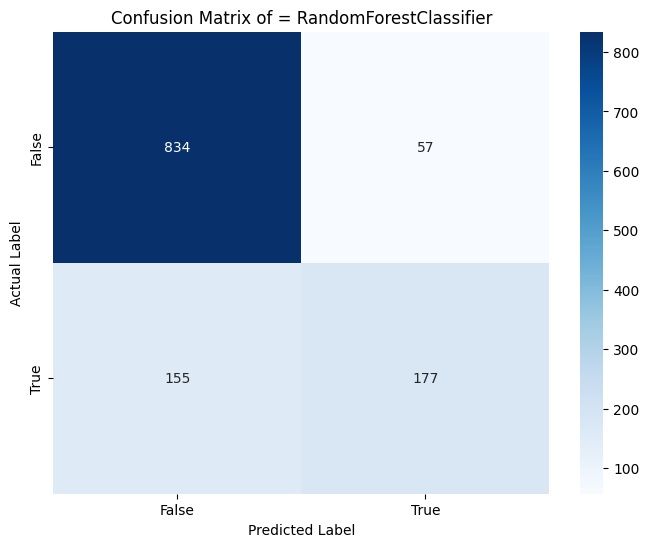

None
               feature  importance
12    Latitude_Degrees    0.098193
13   Longitude_Degrees    0.090033
2            Other_PC3    0.060965
5            Other_PC6    0.056187
15             Depth_m    0.054834
6            Other_PC7    0.054276
4            Other_PC5    0.052767
1            Other_PC2    0.051203
18  Temperature_Kelvin    0.049506
10          Other_PC11    0.049382
0            Other_PC1    0.047941
7            Other_PC8    0.046494
9           Other_PC10    0.043820
8            Other_PC9    0.042828
3            Other_PC4    0.042808
11          Other_PC12    0.041569
16                SSTA    0.040061
14             ClimSST    0.039711
17            SSTA_DHW    0.037424
LGBMClassifier score = 0.8144
[[783 108]
 [119 213]]
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       891
           1       0.66      0.64      0.65       332

    accuracy                           0.81      1223
   macro avg       0.77 

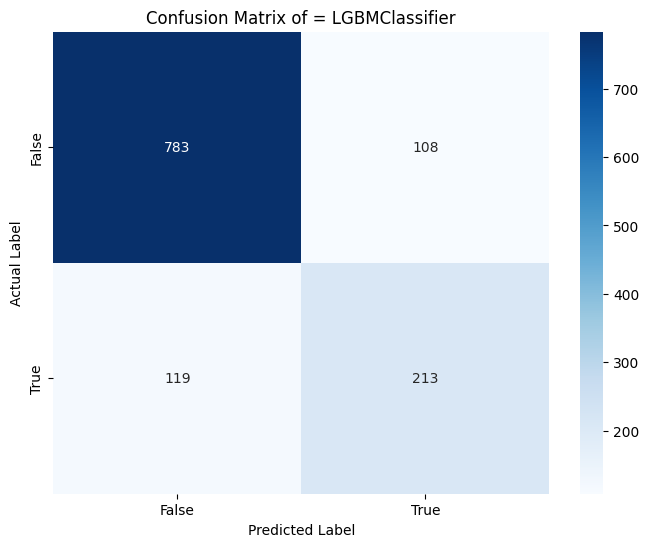

None
               feature  importance
15             Depth_m        2780
16                SSTA        1583
11          Other_PC12        1507
4            Other_PC5        1490
13   Longitude_Degrees        1439
6            Other_PC7        1393
7            Other_PC8        1371
12    Latitude_Degrees        1362
0            Other_PC1        1347
5            Other_PC6        1288
10          Other_PC11        1266
14             ClimSST        1210
8            Other_PC9        1202
9           Other_PC10        1140
3            Other_PC4        1131
18  Temperature_Kelvin        1116
1            Other_PC2        1087
2            Other_PC3        1047
17            SSTA_DHW         998
XGBClassifier score = 0.8111
[[819  72]
 [159 173]]
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       891
           1       0.71      0.52      0.60       332

    accuracy                           0.81      1223
   macro avg       0.77  

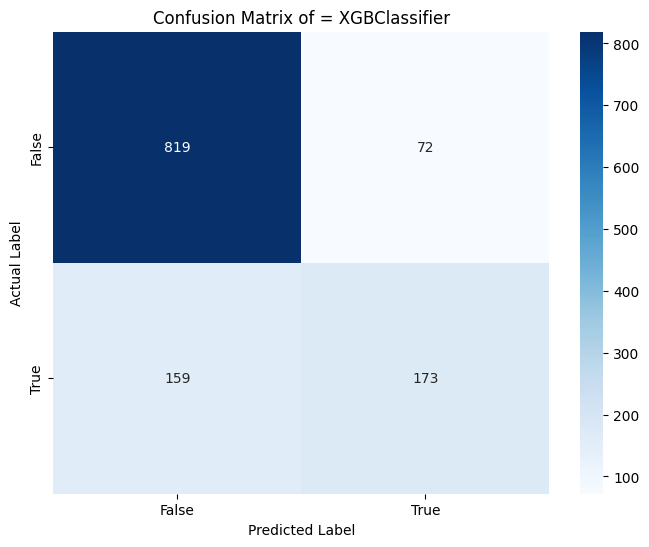

None
               feature  importance
12    Latitude_Degrees    0.091043
13   Longitude_Degrees    0.079964
2            Other_PC3    0.061084
6            Other_PC7    0.056547
5            Other_PC6    0.056521
1            Other_PC2    0.055890
4            Other_PC5    0.052973
18  Temperature_Kelvin    0.049939
17            SSTA_DHW    0.049213
10          Other_PC11    0.049010
14             ClimSST    0.048414
0            Other_PC1    0.047974
9           Other_PC10    0.045004
7            Other_PC8    0.043922
3            Other_PC4    0.043806
11          Other_PC12    0.043744
8            Other_PC9    0.042882
16                SSTA    0.041049
15             Depth_m    0.041020


In [85]:
import warnings
from sklearn.exceptions import DataConversionWarning
# -----------------------------
# ปิด warning
# -----------------------------
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# -----------------------------
# ทำ y เป็น 1D
# -----------------------------
y_train_Class = y_train_Class.ravel()
y_test_Class = y_test_Class.ravel()

# -----------------------------
# Models
# -----------------------------
algo_Class = [
    [RandomForestClassifier(max_features = 'sqrt', max_depth = 16, criterion = 'entropy', bootstrap = False,
                           n_estimators = 300, 
                           random_state = 42), 'RandomForestClassifier'],
    
    [lgb.LGBMClassifier(class_weight='balanced',
                        n_estimators=1000,
                        learning_rate=0.05,
                        max_depth=6,
                        random_state=42,
                        verbose=-1), 'LGBMClassifier'],
    
    [XGBClassifier(n_estimators=500,
                  max_depth=5,            # ไม่ต้องลึกมาก XGBoost ฉลาดพอ
                  learning_rate=0.05,     # ค่อยๆ เรียนรู้ทีละนิด (ยิ่งน้อยยิ่งแม่น แต่เทรนนาน)
                  subsample=0.8,          # สุ่มข้อมูลมาเทรน 80% ต่อรอบ (ช่วยกันจำข้อสอบ)
                  colsample_bytree=0.8,   # สุ่มตัวแปรมา 80% ต่อรอบ
                  random_state=42,
                  n_jobs=-1,
                  verbosity=0), 'XGBClassifier'],
]

results = []
models_Class = {}

for a in algo_Class:

    model = a[0]
    model_name = a[1]

    model.fit(X_train_Class, y_train_Class)

    y_pred = model.predict(X_test_Class)

    score = model.score(X_test_Class, y_test_Class)
    print(f"{a[1]} score = {score:.4f}")

    con_metrix = confusion_matrix(y_test_Class, y_pred)
    print(con_metrix)
    
    clf_report = classification_report(y_test_Class, y_pred)
    print(clf_report)
    
    print(f"AUC: {(roc_auc_score(y_test_Class, y_pred)):.3f}")  # AUC ไม่เปลี่ยน
    print(plot_confusion_matrix(y_test_Class, y_pred, ['False','True'], model_name))
    
    print(feature_importance(model, feature_Classify))
    
    print('='*98)
    
    models_Class[model_name] = model


In [86]:
def Classification_model(X_train, y_train, model, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    oof_preds = np.zeros(len(X_train))  # Out-of-fold predictions
    models = []
    auc_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        print(f"\n===== Fold {fold + 1} / {n_splits} =====")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        clf = model
        clf.fit(X_tr, y_tr)

        # เก็บ OOF predictions
        oof_preds[val_idx] = clf.predict_proba(X_val)[:, 1]
        fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
        auc_scores.append(fold_auc)
        models.append(clf)

        print(f"Fold {fold + 1} AUC: {fold_auc:.4f}")

    oof_auc = roc_auc_score(y_train, oof_preds)
    print(f"\nOOF AUC: {oof_auc:.4f}")
    print(f"Mean CV AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

    return models, oof_preds, auc_scores , clf

In [87]:
for model, model_name in algo_Class:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, auc_scores, model = Classification_model(
        X_train_Class,
        y_train_Class,
        model,
        n_splits=5
    )


========== RandomForestClassifier ==========

===== Fold 1 / 5 =====
Fold 1 AUC: 0.8120

===== Fold 2 / 5 =====
Fold 2 AUC: 0.8322

===== Fold 3 / 5 =====
Fold 3 AUC: 0.8161

===== Fold 4 / 5 =====
Fold 4 AUC: 0.8466

===== Fold 5 / 5 =====
Fold 5 AUC: 0.8275

OOF AUC: 0.8267
Mean CV AUC: 0.8269 ± 0.0123

========== LGBMClassifier ==========

===== Fold 1 / 5 =====
Fold 1 AUC: 0.7939

===== Fold 2 / 5 =====
Fold 2 AUC: 0.8175

===== Fold 3 / 5 =====
Fold 3 AUC: 0.8115

===== Fold 4 / 5 =====
Fold 4 AUC: 0.8443

===== Fold 5 / 5 =====
Fold 5 AUC: 0.8365

OOF AUC: 0.8206
Mean CV AUC: 0.8207 ± 0.0180

========== XGBClassifier ==========

===== Fold 1 / 5 =====
Fold 1 AUC: 0.7962

===== Fold 2 / 5 =====
Fold 2 AUC: 0.8341

===== Fold 3 / 5 =====
Fold 3 AUC: 0.8183

===== Fold 4 / 5 =====
Fold 4 AUC: 0.8463

===== Fold 5 / 5 =====
Fold 5 AUC: 0.8445

OOF AUC: 0.8280
Mean CV AUC: 0.8279 ± 0.0187


##

##

### -----------------------------------------
# Regression model
### -----------------------------------------

In [88]:
def PLOTING_RESULT_ML(model, X_test, y_test, cl, name):

    y_pred = model.predict(X_test).ravel()
    y_test = np.array(y_test).ravel()

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x=y_test,
        y=y_pred,
        alpha=0.5,
        color=cl,
        edgecolor='k'
    )

    # ideal line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red',
        linestyle='--',
        lw=2
    )

    plt.title(f'Actual vs Predicted Percent Bleaching : {name}')
    plt.xlabel('Actual Bleaching (%)')
    plt.ylabel('Predicted Bleaching (%)')

    plt.grid(True, linestyle=':', alpha=0.6)

    plt.show()

#--------------------------------------------------------------------------------------------------------------------------------------------#

def Metric_result(model, X_train, X_test, y_train, y_test):

    y_train = np.array(y_train).ravel()
    y_test = np.array(y_test).ravel()

    print(f"Score on training data: {(model.score(X_train, y_train)):.2f}")

    pred = model.predict(X_test).ravel()

    print("-" * 30)

    test_mse = mean_squared_error(y_test, pred)
    print(f"Test MSE: {test_mse:.2f}")

    print("-" * 30)

    test_rmse = np.sqrt(test_mse)
    print(f"Test RMSE : {test_rmse:.2f}")

    print("-" * 30)

    test_r2 = r2_score(y_test, pred)
    print(f"Test R2 Score : {test_r2:.2f}")

    print("-" * 30)

    test_mae = mean_absolute_error(y_test, pred)
    print(f"Mean Absolute Error : {test_mae:.2f}")

    print("-" * 30)

    test_mape = mean_absolute_percentage_error(y_test, pred) # Mean_Absolute_Percentage_Error
    print(f"Mean Absolute Percentage Error : {test_mape:.2f}")
    print("-" * 30)

In [89]:
def set_feature_target_reg(df):

    feature = df.copy()

    # เลือกเฉพาะ Classify == 1
    feature_reg = feature[feature['Classify'] == 1]

    # target
    target_out = feature_reg[['Percent_Bleaching']]

    # feature
    feature_out = feature_reg.drop(
        columns=['Percent_Bleaching', 'Classify']
    )

    return feature_out, target_out


feature_reg, target_reg = set_feature_target_reg(feature_Class)

In [90]:
X_train_reg, X_test_reg , y_train_reg, y_test_reg = train_test_split(feature_reg.values, target_reg.values, test_size=0.2, random_state=42)
X_train_reg.shape, X_test_reg.shape , y_train_reg.shape, y_test_reg.shape

((1279, 19), (320, 19), (1279, 1), (320, 1))

In [91]:
#------------------------------------------------------------------------#
# Average Bleaching Model — Naïve Baseline
#------------------------------------------------------------------------#

y_true = target_reg.values
y_pred_avg = y_true.mean()  # baseline prediction: predict the mean for every sample

def RMSE(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def R2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    print(f"  SS_res : {ss_res:.1f}")
    print(f"  SS_tot : {ss_tot:.1f}")
    return 1 - (ss_res / ss_tot)

print(f"Baseline prediction (mean): {y_pred_avg:.4f}")
print("-" * 50)
print(f"RMSE    : {RMSE(y_true, y_pred_avg):.2f}")
print(f"R²      : {R2_score(y_true, y_pred_avg):.4f}")

Baseline prediction (mean): 10.5287
--------------------------------------------------
RMSE    : 16.54
  SS_res : 437569.6
  SS_tot : 437569.6
R²      : 0.0000


RandomForestRegressor
Score on training data: 0.92
------------------------------
Test MSE: 170.79
------------------------------
Test RMSE : 13.07
------------------------------
Test R2 Score : 0.47
------------------------------
Mean Absolute Error : 8.22
------------------------------
Mean Absolute Percentage Error : 2.45
------------------------------


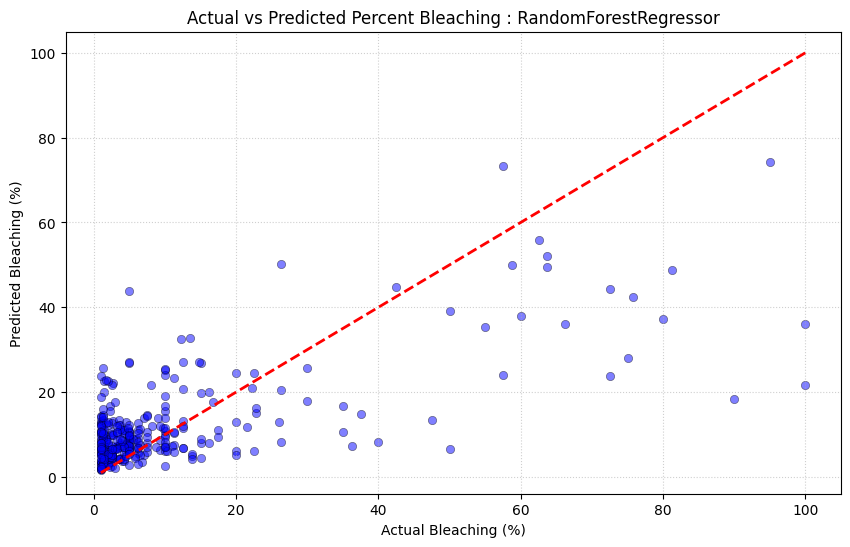

               feature  importance
5            Other_PC6    0.077030
6            Other_PC7    0.075009
10          Other_PC11    0.073806
7            Other_PC8    0.071063
4            Other_PC5    0.062279
17            SSTA_DHW    0.060175
12    Latitude_Degrees    0.059102
18  Temperature_Kelvin    0.057399
13   Longitude_Degrees    0.051993
16                SSTA    0.047540
0            Other_PC1    0.047032
15             Depth_m    0.046892
8            Other_PC9    0.043189
3            Other_PC4    0.040877
2            Other_PC3    0.040342
9           Other_PC10    0.040050
1            Other_PC2    0.039477
11          Other_PC12    0.035625
14             ClimSST    0.031117
LGBMRegressor
Score on training data: 0.89
------------------------------
Test MSE: 175.42
------------------------------
Test RMSE : 13.24
------------------------------
Test R2 Score : 0.46
------------------------------
Mean Absolute Error : 8.25
------------------------------
Mean Absolute Perce

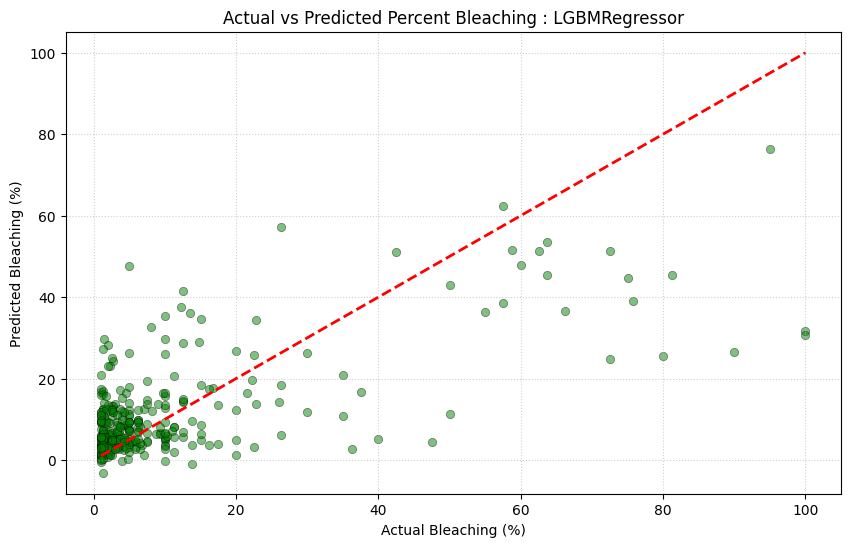

               feature  importance
10          Other_PC11         450
15             Depth_m         426
7            Other_PC8         390
5            Other_PC6         360
6            Other_PC7         357
4            Other_PC5         355
8            Other_PC9         343
18  Temperature_Kelvin         338
16                SSTA         329
9           Other_PC10         323
3            Other_PC4         320
0            Other_PC1         306
11          Other_PC12         296
14             ClimSST         296
17            SSTA_DHW         296
12    Latitude_Degrees         278
2            Other_PC3         235
13   Longitude_Degrees         227
1            Other_PC2         222
XGBRegressor
Score on training data: 0.87
------------------------------
Test MSE: 164.62
------------------------------
Test RMSE : 12.83
------------------------------
Test R2 Score : 0.49
------------------------------
Mean Absolute Error : 7.92
------------------------------
Mean Absolute Percen

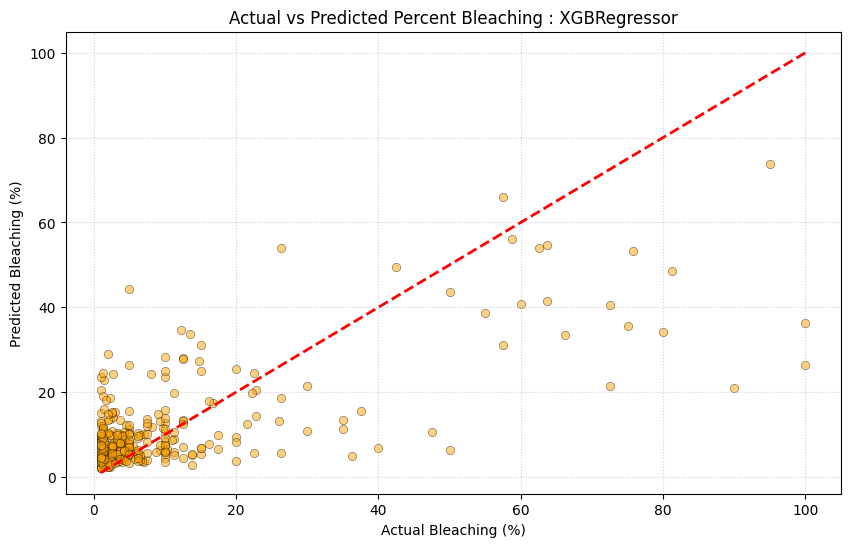

               feature  importance
17            SSTA_DHW    0.083996
7            Other_PC8    0.081877
6            Other_PC7    0.076702
5            Other_PC6    0.069848
4            Other_PC5    0.063060
10          Other_PC11    0.062813
18  Temperature_Kelvin    0.062495
1            Other_PC2    0.047021
12    Latitude_Degrees    0.046684
13   Longitude_Degrees    0.045272
9           Other_PC10    0.045252
14             ClimSST    0.045178
16                SSTA    0.043975
11          Other_PC12    0.041232
0            Other_PC1    0.040624
2            Other_PC3    0.038845
8            Other_PC9    0.038833
3            Other_PC4    0.038328
15             Depth_m    0.027966


In [92]:
algo_reg = [

    [RandomForestRegressor(max_depth=20, 
                           max_features='sqrt', 
                           min_samples_leaf=1, 
                           min_samples_split=2, 
                           n_estimators=500,
                           random_state=42), 'RandomForestRegressor' , 'blue'],
    
    [lgb.LGBMRegressor(colsample_bytree=0.8, 
                       learning_rate=0.05, 
                       max_depth=5, 
                       n_estimators=500, 
                       num_leaves=31, 
                       subsample=0.8,
                       random_state=42), 'LGBMRegressor' , 'green'],
    
    [XGBRegressor(colsample_bytree=0.8, 
                  learning_rate=0.01, 
                  max_depth=5, 
                  min_child_weight=1, 
                  n_estimators=800, 
                  subsample=0.8, 
                  random_state=42), 'XGBRegressor' , 'orange']

]

results_reg = []
models_reg = {}

for r in algo_reg:

    model_reg = r[0]
    model_reg_name = r[1]
    color = r[2]

    # train model
    model_reg.fit(X_train_reg, y_train_reg)

    print(f"{model_reg_name}")
          
    # evaluate
    Metric_result(
        model_reg,
        X_train_reg,
        X_test_reg,
        y_train_reg,
        y_test_reg
    )

    # plot
    PLOTING_RESULT_ML(
        model_reg,
        X_test_reg,
        y_test_reg,
        color,
        f'{model_reg_name}'
    )
    
    print(feature_importance(model_reg, feature_reg))
    
    models_reg[model_reg_name] = model_reg

    print('=' * 98)

In [93]:
def RESULT_K_FOLD(results, cv):
    r2 = results['test_r2']
    rmse = np.sqrt(-results['test_neg_mean_squared_error'])
    mae = -results['test_neg_mean_absolute_error']

    # สร้างฟังก์ชันย่อยสำหรับจัดรูปแบบ array ให้อ่านง่ายขึ้น
    format_folds = lambda arr: ", ".join([f"{x:.2f}" for x in arr])

    print("=" * 60)
    print(f"{'K-Fold Cross Validation Results (CV = ' + str(cv) + ')':^60}")
    print("=" * 60)
    print(f"{'Metric':<10} | {'Mean (Std)':<15} | {'Scores per Fold'}")
    print("-" * 60)
    
    # เพิ่มการดูค่า Standard Deviation (std) ด้วยเพื่อดูความเสถียรของโมเดล
    print(f"{'R2':<10} | {r2.mean():.2f} (±{r2.std():.2f})   | {format_folds(r2)}")
    print(f"{'RMSE':<10} | {rmse.mean():.2f} (±{rmse.std():.2f})   | {format_folds(rmse)}")
    print(f"{'MAE':<10} | {mae.mean():.2f} (±{mae.std():.2f})   | {format_folds(mae)}")
    print("=" * 60)

In [94]:
def Regression_model(X_train, y_train, model, n_splits=5):

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    oof_preds = np.zeros(len(X_train))

    models = []

    rmse_scores = []
    mae_scores = []
    r2_scores = []

    y_train = np.array(y_train).ravel()

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):

        print(f"\n===== Fold {fold+1} / {n_splits} =====")

        # split
        X_tr = X_train[train_idx]
        X_val = X_train[val_idx]

        y_tr = y_train[train_idx]
        y_val = y_train[val_idx]
        
        # train
        reg = model
        reg.fit(X_tr, y_tr)

        # predict
        pred = reg.predict(X_val)

        # save OOF
        oof_preds[val_idx] = pred

        # metrics
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        mae = mean_absolute_error(y_val, pred)
        r2 = r2_score(y_val, pred)

        rmse_scores.append(rmse)
        mae_scores.append(mae)
        r2_scores.append(r2)

        models.append(reg)

        print(f"Fold RMSE : {rmse:.4f}")
        print(f"Fold MAE  : {mae:.4f}")
        print(f"Fold R2   : {r2:.4f}")
        
    print("\n")
    print(f"Mean RMSE : {np.mean(rmse_scores):.4f}")
    print(f"Mean MAE  : {np.mean(mae_scores):.4f}")
    print(f"Mean R2   : {np.mean(r2_scores):.4f}")
    
    print("="*50)

    return (
        models,
        oof_preds,
        rmse_scores,
        mae_scores,
        r2_scores
    )

In [95]:
all_results = []

for model, model_name, color in algo_reg:

    print(f"\n========== {model_name} ==========")

    models, oof_preds, rmse_scores, mae_scores, r2_scores = Regression_model(
        X_train_reg,
        y_train_reg,
        model,
        n_splits=5
    )

    all_results.append({
        'model': model_name,
        'RMSE_mean': np.mean(rmse_scores),
        'MAE_mean': np.mean(mae_scores),
        'R2_mean': np.mean(r2_scores)
    })


========== RandomForestRegressor ==========

===== Fold 1 / 5 =====
Fold RMSE : 12.7075
Fold MAE  : 8.7504
Fold R2   : 0.3446

===== Fold 2 / 5 =====
Fold RMSE : 14.6019
Fold MAE  : 9.0443
Fold R2   : 0.2601

===== Fold 3 / 5 =====
Fold RMSE : 10.8343
Fold MAE  : 7.1174
Fold R2   : 0.3814

===== Fold 4 / 5 =====
Fold RMSE : 11.9327
Fold MAE  : 7.6205
Fold R2   : 0.4880

===== Fold 5 / 5 =====
Fold RMSE : 13.4407
Fold MAE  : 8.8055
Fold R2   : 0.3982


Mean RMSE : 12.7034
Mean MAE  : 8.2676
Mean R2   : 0.3745

========== LGBMRegressor ==========

===== Fold 1 / 5 =====
Fold RMSE : 13.1428
Fold MAE  : 8.6959
Fold R2   : 0.2989

===== Fold 2 / 5 =====
Fold RMSE : 14.5431
Fold MAE  : 8.9823
Fold R2   : 0.2661

===== Fold 3 / 5 =====
Fold RMSE : 11.5356
Fold MAE  : 7.3761
Fold R2   : 0.2987

===== Fold 4 / 5 =====
Fold RMSE : 11.8975
Fold MAE  : 7.6782
Fold R2   : 0.4910

===== Fold 5 / 5 =====
Fold RMSE : 13.7845
Fold MAE  : 8.6893
Fold R2   : 0.3671


Mean RMSE : 12.9807
Mean MAE  : 8.28

##

##

##

=================================
### Testing framework 
- Stage 1 : Classification
- Stage 2 : Regression

=================================

In [96]:
def Data_preparation_test_tage():
    
    feature_test_stage = feature_Class.copy()
    feature_test_stage['Classify'] = (feature_test_stage['Percent_Bleaching'] >= 1).astype(int)
    
    return feature_test_stage , feature_test_stage[['Classify']], feature_test_stage[['Percent_Bleaching']]

feature_test_stage , target_test_stage_one , target_test_stage_two = Data_preparation_test_tage()

In [97]:
print(feature_test_stage[['Classify']].value_counts())
Class_zero = feature_test_stage[feature_test_stage['Classify'] == 0]
print(f"Classify_zero testing stage : {len(Class_zero) // 2} rows")
Class_one = feature_test_stage[feature_test_stage['Classify'] == 1]
print(f"Classify_one testing stage : {len(Class_one) // 2} rows")
print("="*98)
print(f"together Classify  testing stage : {(len(Class_zero) // 2) + (len(Class_one) // 2)} rows")

Classify
0           4513
1           1599
Name: count, dtype: int64
Classify_zero testing stage : 2256 rows
Classify_one testing stage : 799 rows
together Classify  testing stage : 3055 rows


In [98]:
def get_feature_and_target_for_test_stage(feature_df: pd.DataFrame):
    """
    Returns a balanced (50% class 0, 50% class 1) subset of features and targets
    for the test stage, using the first half of each class.
    """
    mask_zero = feature_df['Classify'] == 0
    mask_one  = feature_df['Classify'] == 1

    half_zero = feature_df[mask_zero].iloc[:len(feature_df[mask_zero]) // 2]
    half_one  = feature_df[mask_one ].iloc[:len(feature_df[mask_one])  // 2]
    

    # Stack rows (axis=0), not columns
    feature_subset = pd.concat([half_one, half_zero], axis=0).reset_index(drop=True)
    target_subset_stage_one  = feature_subset[['Classify']]
    target_subset_stage_two = feature_subset[['Percent_Bleaching']]

    return feature_subset, target_subset_stage_one, target_subset_stage_two


# Usage
X_test_stage, y_test_stage_one, y_test_stage_two = get_feature_and_target_for_test_stage(feature_test_stage)

In [99]:
X_test_stage.shape, y_test_stage_one.shape, y_test_stage_two.shape

((3055, 21), (3055, 1), (3055, 1))

In [100]:
#------------------------------------------------------------------------#
# Stage 1 — Classifier (predicts Classify: 0 or 1)
#------------------------------------------------------------------------#

def evaluate_stage_one(feature_df: pd.DataFrame, target_clf: pd.Series, clf_model) -> pd.DataFrame:
    """
    Runs classifier predictions and returns a DataFrame
    labelled with stage=1.
    """
    y_pred = clf_model.predict(feature_df)
    y_prob = clf_model.predict_proba(feature_df)[:, 1] if hasattr(clf_model, "predict_proba") else np.nan

    result_df = pd.DataFrame({
        "y_true"    : target_clf.values,
        "y_pred"    : y_pred,
        "y_prob"    : y_prob,
        "stage"     : 1,
    }, index=feature_df.index)

    return result_df


#------------------------------------------------------------------------#
# Stage 2 — Regressor (predicts percent_bleaching on class 1 only)
#------------------------------------------------------------------------#

def evaluate_stage_two(feature_df: pd.DataFrame, target_reg: pd.Series, reg_model) -> pd.DataFrame:
    """
    Runs regressor predictions on samples that passed stage 1 (Classify == 1)
    and returns a DataFrame labelled with stage=2.
    """
    y_pred = reg_model.predict(feature_df)

    result_df = pd.DataFrame({
        "y_true"    : target_reg.values,
        "y_pred"    : y_pred,
        "y_prob"    : np.nan,           # not applicable for regression
        "stage"     : 2,
    }, index=feature_df.index)

    return result_df


#------------------------------------------------------------------------#
# Combine both stages into one evaluation DataFrame
#------------------------------------------------------------------------#

def build_evaluation_df(
    feature_s1, target_s1, clf_model,
    feature_s2, target_s2, reg_model
) -> pd.DataFrame:

    stage1_df = evaluate_stage_one(feature_s1, target_s1, clf_model)
    stage2_df = evaluate_stage_two(feature_s2, target_s2, reg_model)

    eval_df = pd.concat([stage1_df, stage2_df], axis=0).reset_index(drop=True)

    return eval_df


#------------------------------------------------------------------------#
# Compute metrics per stage
#------------------------------------------------------------------------#

def compute_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes metrics for each stage separately.
    Stage 1 → Accuracy, F1
    Stage 2 → RMSE, R²
    """
    rows = []

    for stage, group in eval_df.groupby("stage"):
        y_true = group["y_true"].values
        y_pred = group["y_pred"].values

        if stage == 1:
            accuracy = np.mean(y_true == y_pred)
            tp = np.sum((y_true == 1) & (y_pred == 1))
            fp = np.sum((y_true == 0) & (y_pred == 1))
            fn = np.sum((y_true == 1) & (y_pred == 0))
            f1 = tp / (tp + 0.5 * (fp + fn)) if (tp + fp + fn) > 0 else 0.0

            rows.append({
                "stage"   : stage,
                "metric1" : round(accuracy, 4),
                "label1"  : "Accuracy",
                "metric2" : round(f1, 4),
                "label2"  : "F1",
            })

        elif stage == 2:
            ss_res = np.sum((y_true - y_pred) ** 2)
            ss_tot = np.sum((y_true - y_true.mean()) ** 2)
            rmse   = np.sqrt(np.mean((y_true - y_pred) ** 2))
            r2     = 1 - (ss_res / ss_tot)

            rows.append({
                "stage"   : stage,
                "metric1" : round(rmse, 4),
                "label1"  : "RMSE",
                "metric2" : round(r2, 4),
                "label2"  : "R²",
            })

    metrics_df = pd.DataFrame(rows)
    return metrics_df


In [101]:
X_test_Class.shape

(1223, 19)

In [102]:
feature_run_test = X_test_stage.drop(columns=['Percent_Bleaching', 'Classify'])
feature_run_test.shape

(3055, 19)

In [103]:
import matplotlib.gridspec as gridspec


#------------------------------------------------------------------------#
# Plot 1 — Confusion Matrix (Stage 1 Classifier)
#------------------------------------------------------------------------#

def plot_stage_one_confusion(stage1_df: pd.DataFrame, clf_name: str, ax=None):
    """
    Plots a styled confusion matrix from stage1_df.
    """
    y_true = stage1_df["y_true"].values
    y_pred = stage1_df["y_pred"].values
    cm     = confusion_matrix(y_true, y_pred)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot      = True,
        fmt        = "d",
        cmap       = "Blues",
        linewidths = 0.8,
        linecolor  = "white",
        xticklabels = ["Pred 0", "Pred 1"],
        yticklabels = ["True 0", "True 1"],
        ax          = ax,
        annot_kws   = {"size": 14, "weight": "bold"},
    )

    # accuracy / f1 subtitle
    tp = cm[1, 1]; fp = cm[0, 1]; fn = cm[1, 0]; tn = cm[0, 0]
    acc = (tp + tn) / cm.sum()
    f1  = tp / (tp + 0.5 * (fp + fn)) if (tp + fp + fn) > 0 else 0

    ax.set_title(f"{clf_name}\nAcc={acc:.3f}  F1={f1:.3f}", fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual",    fontsize=10)


#------------------------------------------------------------------------#
# Plot 2 — Regression Scatter (Stage 2 Regressor)
#------------------------------------------------------------------------#

def plot_stage_two_regression(stage2_df: pd.DataFrame, clf_name: str, reg_name: str, ax=None):
    """
    Plots y_true vs y_pred scatter with residual reference line.
    """
    y_true = stage2_df["y_true"].values
    y_pred = stage2_df["y_pred"].values

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    rmse   = np.sqrt(np.mean((y_true - y_pred) ** 2))
    r2     = 1 - (ss_res / ss_tot)

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    # scatter points
    ax.scatter(y_true, y_pred, alpha=0.4, s=18, color="#2196F3", edgecolors="none")

    # perfect prediction line
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="#F44336", linewidth=1.5, linestyle="--", label="Perfect fit")

    ax.set_title(f"{clf_name}  +  {reg_name}\nRMSE={rmse:.3f}  R²={r2:.3f}",
                 fontsize=10, fontweight="bold", pad=10)
    ax.set_xlabel("y_true (% bleaching)", fontsize=9)
    ax.set_ylabel("y_pred (% bleaching)", fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlim(lims); ax.set_ylim(lims)


#------------------------------------------------------------------------#
# Combined plot — all 9 combinations in one figure
#------------------------------------------------------------------------#

def plot_all_results(eval_results: list, model_clf: list, model_reg: list):

    n_clf = len(model_clf)
    n_reg = len(model_reg)

    fig = plt.figure(figsize=(6 * n_clf, 5 * (n_reg + 1)))
    fig.suptitle("Two-Stage Pipeline — Evaluation Results", fontsize=15, fontweight="bold", y=1.01)
    gs  = gridspec.GridSpec(n_reg + 1, n_clf, figure=fig, hspace=0.55, wspace=0.35)

    clf_names = [name for _, name in model_clf]
    reg_names = [name for _, name in model_reg]

    from collections import defaultdict
    by_clf = defaultdict(list)
    for r in eval_results:
        by_clf[r["clf_name"]].append(r)

    # ── Top row: confusion matrices ──────────────────────────────────────
    for col, clf_name in enumerate(clf_names):
        ax           = fig.add_subplot(gs[0, col])
        first_result = by_clf[clf_name][0]

        # ✓ fix — use stage1_df stored separately, not sliced from combined eval_df
        stage1_data  = first_result["stage1_df"]        # ← key fix
        plot_stage_one_confusion(stage1_data, clf_name, ax=ax)

    # ── Bottom rows: regression scatter ──────────────────────────────────
    for row, reg_name in enumerate(reg_names):
        for col, clf_name in enumerate(clf_names):
            match       = next(r for r in eval_results
                               if r["clf_name"] == clf_name and r["reg_name"] == reg_name)

            # ✓ fix — use stage2_df stored separately
            stage2_data = match["stage2_df"]            # ← key fix
            ax          = fig.add_subplot(gs[row + 1, col])
            plot_stage_two_regression(stage2_data, clf_name, reg_name, ax=ax)

    plt.tight_layout()
    plt.savefig("pipeline_evaluation.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
#------------------------------------------------------------------------#
# Stage 1 — Classifier on all rows
#------------------------------------------------------------------------#


def run_stage_one(feature_df: pd.DataFrame, target_clf: pd.Series, clf_model) -> pd.DataFrame:
    """
    Input  : 1000 rows
    Output : DataFrame with original index preserved + stage=1 label
    """
    y_pred = clf_model.predict(feature_df)
    
    y_true = np.array(target_clf).ravel()

    stage1_df = pd.DataFrame({
        "y_true"     : y_true,              # true class  (0 or 1)
        "y_pred"     : y_pred,              # predicted class (0 or 1)
        "stage"      : 1,
    }, index=feature_df.index)             # ← keep original row index

    return stage1_df


#------------------------------------------------------------------------#
# Filter — pass only predicted class 1 rows to stage 2
#------------------------------------------------------------------------#

def filter_predicted_positive(stage1_df: pd.DataFrame, feature_df: pd.DataFrame, target_reg: pd.Series):
    """
    From stage 1 output (1000 rows), keep only rows predicted as class 1.
    
    Returns:
        feature_s2  : features  for those ~550 rows  (for model input)
        target_s2   : y_true bleaching for those same rows (for evaluation)
        passed_idx  : the original index — so we never lose track of which rows these are
    """
    passed_idx  = stage1_df[stage1_df["y_pred"] == 1].index  # e.g. 550 indices

    feature_s2  = feature_df.loc[passed_idx]      # 550 × n_features
    target_s2   = target_reg.loc[passed_idx]       # 550 true bleaching values ← key line

    return feature_s2, target_s2, passed_idx


#------------------------------------------------------------------------#
# Stage 2 — Regressor on ~550 rows
#------------------------------------------------------------------------#

def run_stage_two(feature_s2: pd.DataFrame, target_s2: pd.Series, reg_model) -> pd.DataFrame:
    """
    Input  : ~550 rows that stage 1 predicted as class 1
    Output : DataFrame with original index preserved + stage=2 label
    """
    y_pred = reg_model.predict(feature_s2)
    
    # ✓ flatten to 1D in case target comes in as shape (n, 1)
    y_true = np.array(target_s2).ravel()

    stage2_df = pd.DataFrame({
        "y_true"    : y_true,              # correct bleaching % for these rows
        "y_pred"    : y_pred,              # predicted bleaching %
        "stage"     : 2,
    }, index=feature_s2.index)            # ← same original index carried through

    return stage2_df



In [105]:
model_clf = [
    [models_Class['RandomForestClassifier'], 'RandomForestClassifier'],
    [models_Class['LGBMClassifier'], 'LGBMClassifier'],
    [models_Class['XGBClassifier'], 'XGBClassifier']
]

model_reg = [
    [models_reg['RandomForestRegressor'], 'RandomForestRegressor'],
    [models_reg['LGBMRegressor'], 'LGBMRegressor'],
    [models_reg['XGBRegressor'], 'XGBRegressor']
]


#------------------------------------------------------------------------#
# Full pipeline — 3 classifiers × 3 regressors = 9 combinations
#------------------------------------------------------------------------#

eval_results = []

for clf_model, clf_name in model_clf:

    # Step 1 — pass DataFrame directly, NOT .values
    stage1_df = run_stage_one(feature_run_test, y_test_stage_one, clf_model)

    print(f"\n{'='*60}")
    print(f"Classifier         : {clf_name}")
    print(f"Total rows         : {len(stage1_df)}")
    print(f"Predicted class 0  : {(stage1_df['y_pred'] == 0).sum()}")
    print(f"Predicted class 1  : {(stage1_df['y_pred'] == 1).sum()}")

    # Step 2 — pass DataFrame/Series directly, NOT .values
    feature_s2, target_s2, passed_idx = filter_predicted_positive(
        stage1_df, feature_run_test, y_test_stage_two
    )

    print(f"Rows sent to stage 2 : {len(feature_s2)}")

    for reg_model, reg_name in model_reg:

        # Step 3
        stage2_df = run_stage_two(feature_s2, target_s2, reg_model)

        # Step 4
        combined_df = pd.concat([stage1_df, stage2_df], axis=0)
        metrics_df  = compute_metrics(combined_df)

        print(f"\n  Regressor : {reg_name}")
        print(metrics_df.to_string(index=False))

        # Step 5
        eval_results.append({
            "clf_name" : clf_name,
            "reg_name" : reg_name,
            "metrics"  : metrics_df,
            "eval_df"  : combined_df,
            "stage1_df" : stage1_df,   # ← added
            "stage2_df" : stage2_df,   # ← added
        })
        

#------------------------------------------------------------------------#
# Summary table
#------------------------------------------------------------------------#

summary_rows = []

for r in eval_results:
    m = r["metrics"].set_index("stage")
    summary_rows.append({
        "Classifier" : r["clf_name"],
        "Regressor"  : r["reg_name"],
        "Accuracy"   : m.loc[1, "metric1"],
        "F1"         : m.loc[1, "metric2"],
        "RMSE"       : m.loc[2, "metric1"],
        "R²"         : m.loc[2, "metric2"],
    })
    
    

summary_df = pd.DataFrame(summary_rows)
print("\n", summary_df.to_string(index=False))




Classifier         : RandomForestClassifier
Total rows         : 3055
Predicted class 0  : 2349
Predicted class 1  : 706
Rows sent to stage 2 : 706

  Regressor : RandomForestRegressor
 stage  metric1   label1  metric2 label2
     1   0.9349 Accuracy   0.8678     F1
     2  10.0189     RMSE   0.6405     R²

  Regressor : LGBMRegressor
 stage  metric1   label1  metric2 label2
     1   0.9349 Accuracy   0.8678     F1
     2  10.2350     RMSE   0.6249     R²

  Regressor : XGBRegressor
 stage  metric1   label1  metric2 label2
     1   0.9349 Accuracy   0.8678     F1
     2  10.0398     RMSE   0.6390     R²

Classifier         : LGBMClassifier
Total rows         : 3055
Predicted class 0  : 2238
Predicted class 1  : 817
Rows sent to stage 2 : 817

  Regressor : RandomForestRegressor
 stage  metric1   label1  metric2 label2
     1   0.9214 Accuracy   0.8515     F1
     2   9.8855     RMSE   0.6156     R²

  Regressor : LGBMRegressor
 stage  metric1   label1  metric2 label2
     1   0.9214 A

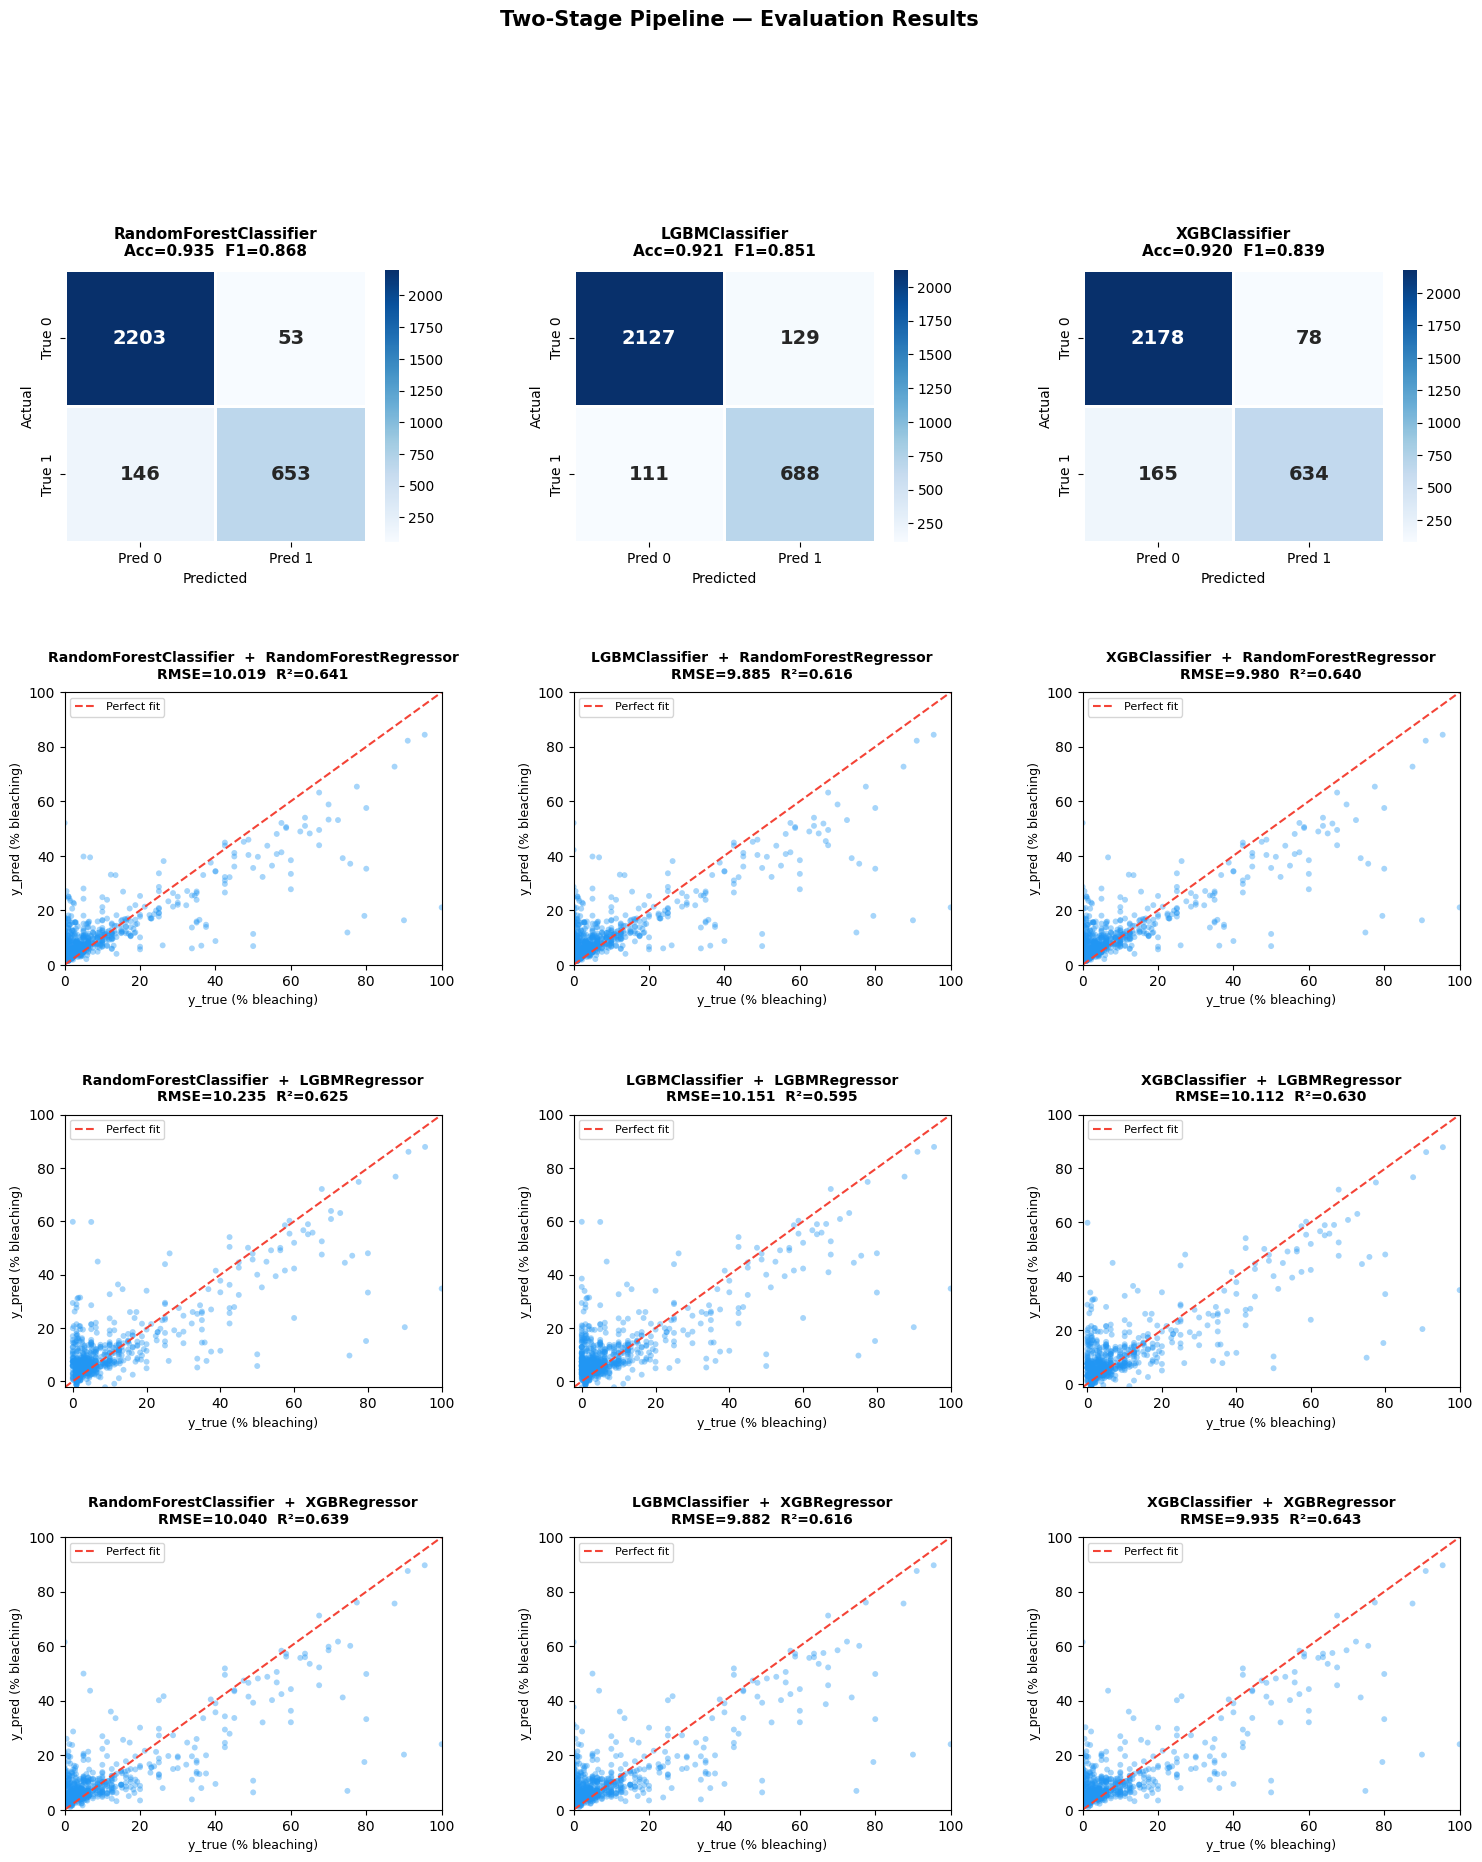

In [106]:
plot_all_results(eval_results, model_clf, model_reg)

In [107]:
# ── Debug — check what's actually stored in stage1_df ─────────────────
for r in eval_results:
    if r["clf_name"] == "RandomForestClassifier":
        s1 = r["stage1_df"]
        print(f"Rows in stage1_df      : {len(s1)}")
        print(f"y_pred == 0            : {(s1['y_pred'] == 0).sum()}")
        print(f"y_pred == 1            : {(s1['y_pred'] == 1).sum()}")
        print(f"y_true unique values   : {s1['y_true'].unique()}")
        print(f"y_pred unique values   : {s1['y_pred'].unique()}")
        print(f"\nConfusion matrix:")
        print(confusion_matrix(s1['y_true'], s1['y_pred']))
        break

Rows in stage1_df      : 3055
y_pred == 0            : 2349
y_pred == 1            : 706
y_true unique values   : [1 0]
y_pred unique values   : [0 1]

Confusion matrix:
[[2203   53]
 [ 146  653]]
